## Contextual Multi-armed Bandit    

As an example, we consider the contextual multi-armed bandit problem: predicting the optimal action of several options, where the cost of each action depends on contextual information.

Both the cost of each arm $\bold{z}$ and the contextual information are random variables

$\bold{x},\bold{z} \sim P$ 

We have $J$ bandits, and 2-dimensions of contextual info
$\bold{x} \in  \mathbb{R}^2$, $\bold{z} \in \mathbb{R}^J$

For each sample of contextual information, we need to choose one of J actions. This is represented by the decision variable $\bold{w}$. Because we can only choose one action, our decisions $\bold{w}$ are in the set of $J$-dimensional 1-hot vectors

$\bold{w} \in \{0,1\}^J, \sum_{j=1}^{J} w_j = 1$

To use our contextual information, we define a function $\bold{w}_{\theta}(\bold{x})$ parameterized by $\theta$ which maps from our input $\bold{x}$ to decision $\bold{w}$.

This makes the cost function of this decision problem:

$c(\bold{w}_{\theta}(\bold{x}),\bold{z}) = \bold{w}_{\theta}(\bold{x})^{\intercal} \bold{z}$

To estimate model parameters $\theta$, we minimize the expected cost over our training dataset
 
 $$\min_{\theta \in \Theta} \mathbb{E}_{(\bold{x},\bold{z}) \sim \mathcal{D}} \left[ c(\bold{w}_{\theta}(\bold{x}),\bold{z}) \right] = \frac{1}{n} \sum_{i=1}^{n} \bold{w}_\theta^\intercal \bold{z}$$

By estimating the model parameters while simultaneously optimizing the decision-making process, we obtain what is called the Integrated Estimation Objective (IEO).

$$\hat{\theta}^\text{IEO} = \inf_{\theta \in \Theta} \mathbb{E}_{(\bold{x},\bold{z}) \sim \mathcal{D}} \left[ c(\bold{w}_{\theta}(\bold{x}),\bold{z}) \right] =  \inf_{\theta \in \Theta} \frac{1}{n} \sum_{i=1}^{n} \bold{w}_\theta^\intercal \bold{z}$$

It is not always feasible to calculate this infimum using gradient descent techniques. Because $\bold{w}$ is one-hot, the derivative with respect to $\theta$ is 0 everyhwere except the transition between decisions. 

To get around this, we can replace the cost function with one of several differentiable surrogates. We consider the following options

### DPO
The method of differentiable perturbed optimizers (berthet I hope et al 2020) works by adding random noise to inputs and taking the expected decision 

### DPO

For a (stochastic) perturbed optimizer with noise $\boldsymbol{\xi}$ and temperature $\varepsilon>0$, define the (Monte‑Carlo) *soft* decision
$$
\hat{\pi}_\varepsilon(\boldsymbol{t})
\;\approx\;
\frac1{M}\sum_{m=1}^M \hat{\pi}(\boldsymbol{t}+\varepsilon \boldsymbol{\xi}^{(m)}),
\qquad
\hat{\pi}(\boldsymbol{t}) \in \arg\min_{\boldsymbol{w}\in\mathcal{W}} \boldsymbol{t}^\top \boldsymbol{w}.
$$

The IEO estimate under DPO is
$$
\hat{\theta}^{IEO}_{DPO}
\;\in\;
\arg\min_{\theta\in\Theta}\;
\frac1n \sum_{i=1}^n
\; \boldsymbol{z}_i^\top \hat{\pi}_\varepsilon\!\bigl(f_\theta(\boldsymbol{x}_i)\bigr).
$$


### SPO+
Smart, Predict-then Optimize Replaces the cost with a surrogate cost

### SPO+

For linear objectives over a discrete feasible set $\mathcal{W}$, the SPO loss is
$$
\ell_{\mathrm{SPO}}(\boldsymbol{t},\boldsymbol{z})
=
\boldsymbol{z}^\top \hat{\pi}(\boldsymbol{t})-\min_{\boldsymbol{w}\in\mathcal{W}} \boldsymbol{z}^\top \boldsymbol{w}.
$$
The SPO$^+$ surrogate is
$$
\ell_{\mathrm{SPO}^+}(\boldsymbol{t},\boldsymbol{z})
=
\max_{\boldsymbol{w}\in\mathcal{W}} (\boldsymbol{z}-2\boldsymbol{t})^\top \boldsymbol{w}
+2\boldsymbol{t}^\top \hat{\pi}(\boldsymbol{z})
-\boldsymbol{z}^\top \hat{\pi}(\boldsymbol{z}).
$$

The IEO estimate under SPO$^+$ is
$$
\hat{\theta}^{IEO}_{SPO^+}
\;\in\;
\arg\min_{\theta\in\Theta}\;
\frac1n \sum_{i=1}^n
\ell_{\mathrm{SPO}^+}\!\bigl(f_\theta(\boldsymbol{x}_i),\boldsymbol{z}_i\bigr).
$$


### PG
Perturbed gradient does the same

### PG

Let $V(\boldsymbol{t})=\min_{\boldsymbol{w}\in\mathcal{W}} \boldsymbol{t}^\top \boldsymbol{w}$.
The downstream decision loss satisfies (directional derivative / Danskin):
$$
\ell(\boldsymbol{t},\boldsymbol{z})=\boldsymbol{z}^\top \hat{\pi}(\boldsymbol{t}).
$$
The perturbation‑gradient (PG) losses are finite‑difference surrogates:
$$
\hat{\ell}^{\,b}_h(\boldsymbol{t},\boldsymbol{z})=\frac{V(\boldsymbol{t})-V(\boldsymbol{t}-h\boldsymbol{z})}{h},
\qquad
\hat{\ell}^{\,c}_h(\boldsymbol{t},\boldsymbol{z})=\frac{V(\boldsymbol{t}+h\boldsymbol{z})-V(\boldsymbol{t}-h\boldsymbol{z})}{2h}.
$$

The IEO estimate under PG (e.g., backward) is
$$
\hat{\theta}^{IEO}_{PG}
\;\in\;
\arg\min_{\theta\in\Theta}\;
\frac1n \sum_{i=1}^n
\hat{\ell}^{\,b}_h\!\bigl(f_\theta(\boldsymbol{x}_i),\boldsymbol{z}_i\bigr).
$$


As $n \rightarrow \infty$, do all of these converge to the same solution? I'm actually not sure.

Let's assume they do.

We know that for well-specified models ($\exists \theta_0 \in \Theta s.t. P = P_{\theta_0}$), the regret of the decision induced by $\theta^{\text{IEO}}$ is vanishing as $n \rightarrow \infty$.

We also know that the quantity $\sqrt{n}(\hat{\theta}^{IEO} -\theta^*)$ is asympotically normal with 0 mean and a known covariance matrix. Here $\theta^*$ is the optimial model parameter.

Furthermore we know that a smaller covariance matrix implies that the regret of one decision stochastically dominates the regret of a decision induced by model parameters with a larger covariance matrix.

I would like to show a stochastic dominance relationship between $\hat{\theta}^{IEO}_{PG}, \hat{\theta}^{IEO}_{SPO+},\hat{\theta}^{IEO}_{DPO}$

This means we need to calculate the covariance matrices:

$$\Bigl( \nabla_{\theta\theta} v_0(\bold{w}_{\theta^*}) \Bigr)^{-1}
  \, \text{Cov}_P\!\bigl( \nabla_{\theta} c(\bold{w}_{\theta^*},\bold{z}) \bigr)
  \, \Bigl( \nabla_{\theta\theta} v_0(\bold{w}_{\theta^*}) \Bigr)^{-1}$$

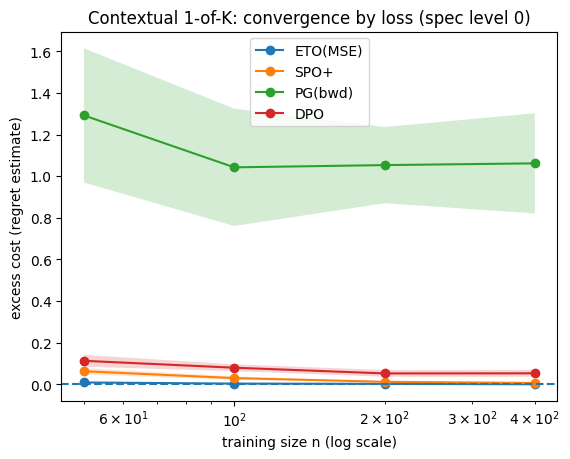

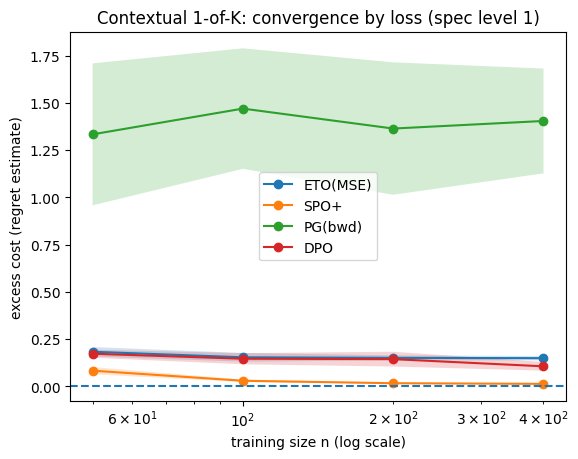

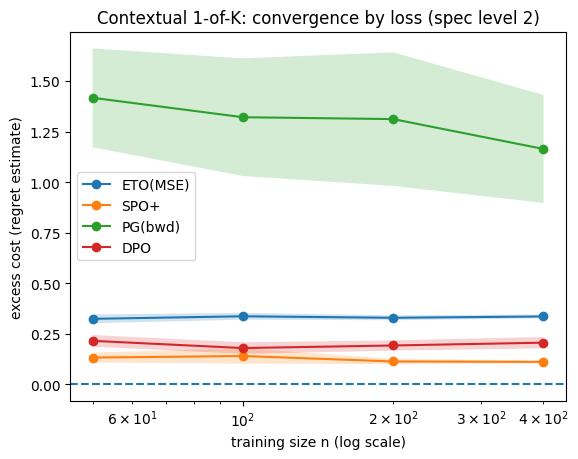

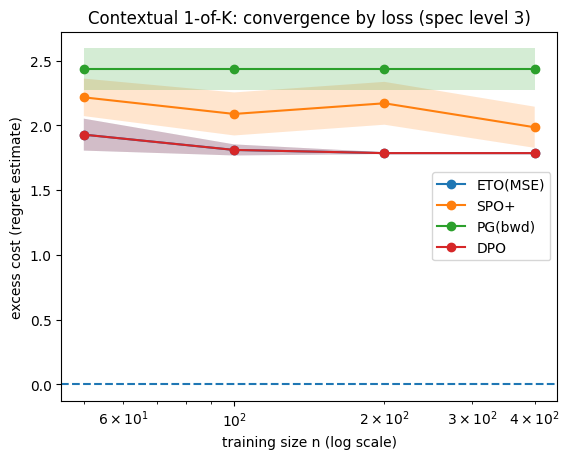

Done. `results[(spec, loss_name)]` holds (n, mean regret, std) for each curve.


In [2]:
# --- Synthetic contextual 1-of-K decision problem + IEO experiments ---
# This cell is self-contained: defines the DGP, misspecification ladder, IEO losses, optimization, and evaluation.

import math
import numpy as np
import torch
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
device = torch.device("cpu")

# -----------------------
# 1) Contextual 1-of-K setup
# -----------------------
@dataclass
class BanditDGP:
    K: int = 8          # number of actions
    p: int = 2          # context dimension
    noise_std: float = 0.3
    seed: int = 0

    def __post_init__(self):
        rng = np.random.default_rng(self.seed)
        # True feature map uses nonlinear + interaction terms
        # phi_true(x) in R^d_true
        self.d_true = 7
        # True weights map phi_true -> cost vector in R^K
        self.W_true = rng.normal(scale=1.0, size=(self.K, self.d_true))
        self.b_true = rng.normal(scale=0.2, size=(self.K,))
        # Make arms meaningfully different
        self.W_true += np.linspace(-0.6, 0.6, self.K)[:, None]

    def phi_true(self, x: np.ndarray) -> np.ndarray:
        # x shape (...,2)
        x1 = x[..., 0]
        x2 = x[..., 1]
        return np.stack([
            x1,
            x2,
            x1**2,
            x2**2,
            x1*x2,
            np.sin(np.pi * x1),
            np.sin(np.pi * x2),
        ], axis=-1)

    def f_star(self, x: np.ndarray) -> np.ndarray:
        # conditional mean of costs, shape (...,K)
        phi = self.phi_true(x)  # (..., d_true)
        return phi @ self.W_true.T + self.b_true

    def sample(self, n: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
        # contexts uniform on [-1,1]^p
        x = rng.uniform(-1.0, 1.0, size=(n, self.p))
        mean = self.f_star(x)
        z = mean + rng.normal(0.0, self.noise_std, size=mean.shape)
        return x, z

# decision: one-hot at argmin
def pi_hat(t: torch.Tensor) -> torch.Tensor:
    # t: (n,K) -> (n,K) one-hot
    idx = torch.argmin(t, dim=-1)
    return torch.nn.functional.one_hot(idx, num_classes=t.shape[-1]).to(t.dtype)

def V_of(t: torch.Tensor) -> torch.Tensor:
    # (n,K) -> (n,)
    return torch.min(t, dim=-1).values

# -----------------------
# 2) Misspecification ladder via feature maps
# -----------------------
def features_spec(level: int) -> Callable[[torch.Tensor], torch.Tensor]:
    # x: (n,2) -> phi: (n,d)
    # level 0: well-specified (matches DGP feature basis)
    # level 1: mildly misspecified (quadratic + linear, no sin)
    # level 2: more misspecified (linear only)
    # level 3: severe misspecified (constant only)
    if level == 0:
        def phi(x):
            x1, x2 = x[:,0], x[:,1]
            return torch.stack([x1, x2, x1**2, x2**2, x1*x2, torch.sin(math.pi*x1), torch.sin(math.pi*x2)], dim=-1)
        return phi
    if level == 1:
        def phi(x):
            x1, x2 = x[:,0], x[:,1]
            return torch.stack([x1, x2, x1**2, x2**2, x1*x2], dim=-1)
        return phi
    if level == 2:
        def phi(x):
            x1, x2 = x[:,0], x[:,1]
            return torch.stack([x1, x2], dim=-1)
        return phi
    if level == 3:
        def phi(x):
            return torch.ones((x.shape[0], 1), dtype=x.dtype, device=x.device)
        return phi
    raise ValueError("level must be in {0,1,2,3}")

class LinearCostModel(torch.nn.Module):
    def __init__(self, K: int, phi: Callable[[torch.Tensor], torch.Tensor], d: int):
        super().__init__()
        self.K = K
        self.phi = phi
        self.W = torch.nn.Parameter(torch.zeros((K, d), dtype=torch.float64))
        self.b = torch.nn.Parameter(torch.zeros((K,), dtype=torch.float64))
        torch.nn.init.normal_(self.W, std=0.2)
        torch.nn.init.normal_(self.b, std=0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        Phi = self.phi(x)  # (n,d)
        return Phi @ self.W.T + self.b  # (n,K)

# -----------------------
# 3) Losses: ETO (MSE), SPO+, PG, DPO
# -----------------------
def loss_mse(t: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    return torch.mean((t - z)**2)

def loss_spoplus(t: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    # ℓ_SPO+(t,z) = max_w (z-2t)^T w + 2 t^T pi(z) - z^T pi(z)
    # For one-hot W, max_w is max_j (z_j - 2 t_j)
    term1 = torch.max(z - 2*t, dim=-1).values
    pi_z = pi_hat(z)  # tie-broken by argmin
    term2 = 2.0 * torch.sum(t * pi_z, dim=-1)
    term3 = torch.sum(z * pi_z, dim=-1)
    return torch.mean(term1 + term2 - term3)


def loss_spoplus_smooth(t: torch.Tensor, z: torch.Tensor, tau: float = 0.25) -> torch.Tensor:
    """
    Smooth SPO+ surrogate for 1-of-K.
    Replaces max_j (z_j - 2 t_j) with tau * logsumexp((z_j - 2 t_j)/tau).
    tau -> 0 recovers the original (nonsmooth) term.
    Returns per-example loss vector of shape (n,).
    """
    # term1: smooth max
    term1 = tau * torch.logsumexp((z - 2.0*t) / tau, dim=-1)
    # pi(z) uses argmin of z (data), so treated as constant wrt theta
    pi_z = pi_hat(z).to(t.dtype)
    term2 = 2.0 * torch.sum(t * pi_z, dim=-1)
    term3 = torch.sum(z * pi_z, dim=-1)
    return term1 + term2 - term3

# global temperature used by LOSS_FNS["SPO+"] (fit_ieo updates this during annealing)
SPO_TAU = 0.25

def loss_pg_backward(t: torch.Tensor, z: torch.Tensor, h: float = 0.25) -> torch.Tensor:
    return torch.mean((V_of(t) - V_of(t - h*z)) / h)

def loss_pg_central(t: torch.Tensor, z: torch.Tensor, h: float = 0.25) -> torch.Tensor:
    return torch.mean((V_of(t + h*z) - V_of(t - h*z)) / (2*h))

def loss_dpo_gumbel(t: torch.Tensor, z: torch.Tensor, eps: float = 0.5) -> torch.Tensor:
    # If xi are i.i.d Gumbel, argmin(t+eps*xi) => softmax over -t/eps
    # expected cost = sum_j z_j * p_j
    p = torch.softmax(-t/eps, dim=-1)
    return torch.mean(torch.sum(z * p, dim=-1))

LOSS_FNS = {
    "ETO(MSE)": lambda t,z: loss_mse(t,z),
    "SPO+":     lambda t,z: loss_spoplus_smooth(t,z,tau=SPO_TAU).mean(),
    "PG(bwd)":  lambda t,z: loss_pg_backward(t,z,h=0.25),
    "DPO":      lambda t,z: loss_dpo_gumbel(t,z,eps=0.5),
}

# -----------------------
# 4) Training loop (IEO = ERM on chosen surrogate)
# -----------------------
def fit_ieo(
    x_train: np.ndarray,
    z_train: np.ndarray,
    K: int,
    spec_level: int,
    loss_name: str,
    steps: int = 1500,
    lr: float = 2e-2,
    batch_size: int = 128,
    seed: int = 0,
) -> LinearCostModel:
    torch.manual_seed(seed)
    np_rng = np.random.default_rng(seed)

    x = torch.tensor(x_train, device=device)
    z = torch.tensor(z_train, device=device)

    phi = features_spec(spec_level)
    d = phi(x[:1]).shape[-1]
    model = LinearCostModel(K=K, phi=phi, d=d).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for step in range(steps):
        idx = np_rng.integers(0, x.shape[0], size=min(batch_size, x.shape[0]))
        xb = x[idx]
        zb = z[idx]
        tb = model(xb)
        # Optional annealing for smooth SPO+ temperature
        global SPO_TAU
        if loss_name == "SPO+":
            tau_start, tau_end = 0.5, 0.05
            frac = step / max(1, steps - 1)
            SPO_TAU = tau_start * (tau_end / tau_start) ** frac

        loss = LOSS_FNS[loss_name](tb, zb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    return model

# -----------------------
# 5) Evaluation: out-of-sample regret vs optimal (true-mean) policy
# -----------------------
@torch.no_grad()
def evaluate_regret(
    dgp: BanditDGP,
    model: LinearCostModel,
    n_test: int = 10000,
    seed: int = 123,
) -> float:
    rng = np.random.default_rng(seed)
    x_te, z_te = dgp.sample(n_test, rng)

    x = torch.tensor(x_te, device=device)
    z = torch.tensor(z_te, device=device)

    # learned plug-in decision
    t_hat = model(x)
    w_hat = pi_hat(t_hat)

    # oracle plug-in decision using true conditional mean
    t_star = torch.tensor(dgp.f_star(x_te), device=device)
    w_star = pi_hat(t_star)

    cost_hat = torch.mean(torch.sum(z * w_hat, dim=-1)).item()
    cost_star = torch.mean(torch.sum(z * w_star, dim=-1)).item()
    return cost_hat - cost_star

# -----------------------
# 6) Run convergence experiments
# -----------------------
dgp = BanditDGP(K=8, p=2, noise_std=0.35, seed=7)

ns = [50, 100, 200, 400]
spec_levels = [0, 1, 2, 3]   # increasing misspecification
n_trials = 10

results = {}  # (spec, loss) -> list of (n, mean, std)

for spec in spec_levels:
    for loss_name in LOSS_FNS.keys():
        curve = []
        for n in ns:
            regrets = []
            for trial in range(n_trials):
                rng = np.random.default_rng(1000 + 17*trial + 100*spec + n)
                x_tr, z_tr = dgp.sample(n, rng)
                model = fit_ieo(
                    x_tr, z_tr, K=dgp.K, spec_level=spec, loss_name=loss_name,
                    steps=1200, lr=2e-2, batch_size=128,
                    seed=2000 + 19*trial + 10*spec
                )
                reg = evaluate_regret(dgp, model, n_test=8000, seed=5000 + trial)
                regrets.append(reg)
            curve.append((n, float(np.mean(regrets)), float(np.std(regrets))))
        results[(spec, loss_name)] = curve

# -----------------------
# 7) Plot: regret vs n for each misspec level
# -----------------------
figs = []
for spec in spec_levels:
    plt.figure()
    for loss_name in LOSS_FNS.keys():
        curve = results[(spec, loss_name)]
        n_arr = np.array([c[0] for c in curve])
        mean = np.array([c[1] for c in curve])
        std = np.array([c[2] for c in curve])
        plt.plot(n_arr, mean, marker='o', label=loss_name)
        plt.fill_between(n_arr, mean - 1.96*std/np.sqrt(n_trials), mean + 1.96*std/np.sqrt(n_trials), alpha=0.2)
    plt.xscale("log")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("training size n (log scale)")
    plt.ylabel("excess cost (regret estimate)")
    plt.title(f"Contextual 1-of-K: convergence by loss (spec level {spec})")
    plt.legend()
    plt.show()

print("Done. `results[(spec, loss_name)]` holds (n, mean regret, std) for each curve.")


## Panel A vs Panel B and theory hooks

This notebook produces empirical *regret vs. sample size* curves for a contextual **1-of-K** decision problem under increasing **model misspecification**.

To connect the experiments to asymptotic theory, it helps to separate two questions:

1. **Parameter asymptotics (M-estimation):** for each loss \(\ell\), the estimator \(\hat\theta\) typically satisfies a CLT of the form  
   \[
   \sqrt{n}(\hat\theta-\theta^{\ell}) \Rightarrow \mathcal N(0,\; H_{\ell}^{-1}J_{\ell}H_{\ell}^{-1})
   \]
   where \(\theta^{\ell}\) is the (possibly *pseudo-true*) population minimizer of the expected loss,  
   \(H_{\ell}=\nabla^2\,\mathbb E[\ell(\theta;Z)]\) and \(J_{\ell}=\mathrm{Var}(\nabla\ell(\theta;Z))\).

2. **Decision/regret asymptotics:** regret depends on \(\arg\min_w \hat c_{\theta}(x,w)\), which is **nonsmooth**.  
   A common way to connect CLTs to regret is via **margins** (cost gaps between the best and second-best action).  
   Different losses can yield different \(\Sigma_{\ell}=H_{\ell}^{-1}J_{\ell}H_{\ell}^{-1}\), which changes the probability of crossing decision boundaries at finite \(n\) (different constants), even when all methods are consistent.

### Panel A vs Panel B (recommended experimental design)

- **Panel A (well-specified):** choose a DGP whose conditional mean costs are *exactly linear* in the richest feature map \(\phi_0(x)\).  
  Then spec level 0 is well-specified; spec 1–3 are controlled misspecifications (projections onto smaller feature classes).

- **Panel B (misspecified):** keep the same DGP but fit with spec levels 1–3, or optionally introduce an additional nonlinear term that is not representable even by \(\phi_0\).  
  Under misspecification, each loss converges to a different pseudo-truth \(\theta^{\ell}\), so **asymptotic regret limits may differ** across losses.


## Sandwich covariance + boundary diagnostics (optional but theory-aligned)

This section is **optional** but useful if you want the plots to “touch theory.”

We:
1. Approximate the population minimizer \(\theta^{\ell}\) by training on a very large synthetic sample.
2. Estimate the **sandwich covariance** \(\Sigma_{\ell}=H^{-1}JH^{-1}\) at that \(\theta^{\ell}\).
3. Use \(\Sigma_{\ell}\) to quantify uncertainty in *pairwise cost gaps*, which governs how often the learned policy crosses a decision boundary.

Notes:
- For PG/DPO, the smoothing parameters (perturbation radius / temperature) effectively change the target objective unless you anneal them with \(n\).
- SPO+ can be nonsmooth; we treat it as differentiable “enough” here for a numerical Hessian estimate. If the Hessian is unstable, increase batch sizes or add a tiny ridge.


### Smoothing SPO+ for curvature / sandwich diagnostics

Classical sandwich covariance formulas assume the objective is (twice) differentiable in the parameters near the pseudo-truth.
The vanilla SPO+ surrogate contains a `max` term, making it **nonsmooth** (piecewise linear) and causing Hessian-based
curvature estimates to be undefined or zero a.e.

To connect SPO+ to the same M-estimation style diagnostics as the other losses, we use a **smoothed SPO+** variant
that replaces `max` with a softmax / log-sum-exp approximation:

\[
\max_j u_j \;\approx\; \tau\,\log\sum_j \exp(u_j/\tau),
\]
where \(\tau>0\) is a temperature. As \(\tau\to 0\), the expression approaches the true max.

**Training (pseudo-truth):** we anneal \(\tau\) from a larger value to a smaller value over gradient steps.  
**Sandwich diagnostics:** we hold a small \(\tau\) fixed (default `spo_tau=0.05`) to estimate curvature of the smoothed objective.


In [3]:


# --- Panel B add-on: pseudo-truth + sandwich covariance + boundary diagnostics ---
# Run after the big experiment cell above (it defines: BanditDGP, features_spec, LOSS_FNS, fit_ieo).
# If you restart the kernel, run the experiment cell first.

import numpy as np, torch, math
from typing import Dict, Tuple
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
device = torch.device("cpu")

# -----------------------
# 0) Optional "strong misspecification" DGP
# -----------------------
class BanditDGP_StrongMisspec(BanditDGP):
    '''
    Adds an extra nonlinear term NOT representable by phi_true / features_spec(0),
    so even spec-0 is misspecified.
    '''
    def __post_init__(self):
        super().__post_init__()
        rng = np.random.default_rng(self.seed + 999)
        self.extra_w = rng.normal(scale=0.7, size=(self.K,))  # arm-specific amplitude

    def f_star(self, x: np.ndarray) -> np.ndarray:
        base = super().f_star(x)
        x1 = x[..., 0]
        x2 = x[..., 1]
        extra = np.sin(2.0*math.pi*(x1 * x2))  # NOT in phi0
        return base + extra[..., None] * self.extra_w[None, :]

# Choose which population you want for theory diagnostics.
PANEL = "B"  # "A" => well-specified wrt phi0; "B" => misspecified (spec<0) but DGP still linear-in-phi0; "B2" => strong misspec even for spec0
K = 8
seed = 123

if PANEL == "A" or PANEL == "B":
    dgp_theory = BanditDGP(K=K, noise_std=0.30, seed=seed)
elif PANEL == "B2":
    dgp_theory = BanditDGP_StrongMisspec(K=K, noise_std=0.30, seed=seed)
else:
    raise ValueError("PANEL must be in {'A','B','B2'}")

# -----------------------
# 1) Helpers: functional cost model + packing theta
# -----------------------
def pack_theta(W: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.cat([W.reshape(-1), b.reshape(-1)])

def unpack_theta(theta: torch.Tensor, K: int, d: int) -> Tuple[torch.Tensor, torch.Tensor]:
    W = theta[:K*d].reshape(K, d)
    b = theta[K*d:K*d+K]
    return W, b

def predict_costs(theta: torch.Tensor, Phi: torch.Tensor, K: int, d: int) -> torch.Tensor:
    W, b = unpack_theta(theta, K, d)
    return Phi @ W.T + b

def empirical_loss(theta: torch.Tensor, Phi: torch.Tensor, z: torch.Tensor, loss_name: str, K: int, d: int) -> torch.Tensor:
    t = predict_costs(theta, Phi, K, d)
    return LOSS_FNS[loss_name](t, z).mean()

# Pairwise gap gradient wrt theta (sparse block structure)
def gap_grad(Phi_row: torch.Tensor, w: int, w_star: int, K: int) -> torch.Tensor:
    d = Phi_row.numel()
    g = torch.zeros(K*d + K, dtype=Phi_row.dtype, device=Phi_row.device)
    g[w*d:(w+1)*d] = Phi_row
    g[w_star*d:(w_star+1)*d] = -Phi_row
    g[K*d + w] = 1.0
    g[K*d + w_star] = -1.0
    return g

# -----------------------
# 2) Approximate population minimizer theta^ell by training on a large sample
# -----------------------
def approximate_pseudotruth(spec_level: int, loss_name: str, n_pop: int = 200_000, steps: int = 2500, lr: float = 2e-2, seed: int = 0):
    rng = np.random.default_rng(seed)
    x_pop, z_pop = dgp_theory.sample(n_pop, rng)
    model = fit_ieo(x_pop, z_pop, K=K, spec_level=spec_level, loss_name=loss_name, steps=steps, lr=lr, batch_size=256, seed=seed)
    with torch.no_grad():
        theta = pack_theta(model.W.detach().cpu(), model.b.detach().cpu())
    return theta

# -----------------------
# 3) Sandwich covariance: Sigma = H^{-1} J H^{-1}
# -----------------------
def estimate_sandwich(theta_star, spec_level, loss_name,
                      n_hess=5000, n_score_batches=200, score_batch_size=256,
                      spo_tau=0.05,
                      ridge=1e-5, seed=0):
    torch.manual_seed(seed)

    # Use a small-but-nonzero smoothing temperature for SPO+ during curvature estimation
    global SPO_TAU
    if loss_name == "SPO+":
        SPO_TAU = float(spo_tau)

    # --- 1) Estimate H: Hessian of average loss over a big batch ---
    x_h, c_h = dgp_theory.sample(n_hess, rng=np.random.default_rng(seed+1))
    x_h = torch.tensor(x_h, device=device, dtype=torch.float64)
    c_h = torch.tensor(c_h, device=device, dtype=torch.float64)
    theta_star = theta_star.detach().clone().requires_grad_(True)
    phi = features_spec(spec_level)(x_h)
    t = predict_costs(theta_star, phi, K=K, d=phi.shape[1])
    L = LOSS_FNS[loss_name](t, c_h)
    if L.dim() > 0:
        L = L.mean()
    # gradient
    g = torch.autograd.grad(L, theta_star, create_graph=True)[0]
    # Hessian via second grads (vector-Jacobian trick)
    p = g.numel()
    H = torch.zeros((p, p), dtype=theta_star.dtype, device=theta_star.device)
    for i in range(p):
        gi = g.reshape(-1)[i]
        if not gi.requires_grad:
            continue
        Hi = torch.autograd.grad(gi, theta_star, retain_graph=True, allow_unused=True, create_graph=False)[0]
        if Hi is not None:
            H[i] = Hi.reshape(-1).detach()

    # --- 2) Estimate J: covariance of batch gradients of average loss ---
    grads = []
    for b in range(n_score_batches):
        x_b, c_b = dgp_theory.sample(score_batch_size, rng=np.random.default_rng(seed+1000+b))
        x_b = torch.tensor(x_b, device=device, dtype=torch.float64)
        c_b = torch.tensor(c_b, device=device, dtype=torch.float64)
        phi_b = features_spec(spec_level)(x_b)
        t_b = predict_costs(theta_star, phi_b, K=K, d=phi_b.shape[1])
        L_b = LOSS_FNS[loss_name](t_b, c_b)
        if L_b.dim() > 0:
            L_b = L_b.mean()
        g_b = torch.autograd.grad(L_b, theta_star, retain_graph=False, create_graph=False)[0].detach()
        grads.append(g_b.reshape(-1))
    G = torch.stack(grads, dim=0)
    J = torch.cov(G.T)

    # --- 3) Sandwich with ridge ---
    H = H + ridge * torch.eye(p, device=H.device, dtype=H.dtype)
    Hinv = torch.linalg.inv(H)
    Sigma = Hinv @ J @ Hinv
    return Sigma, phi.shape[1]
# -----------------------
# 4) Boundary diagnostics: predicted misranking probability from Sigma
# -----------------------
def boundary_diagnostics(theta_star: torch.Tensor, Sigma: torch.Tensor, spec_level: int, n_grid: int = 3000, seed: int = 0):
    rng = np.random.default_rng(seed)
    xg = rng.uniform(-1.0, 1.0, size=(n_grid, 2))
    true_mean = dgp_theory.f_star(xg)  # (n_grid,K)

    xg_t = torch.tensor(xg, dtype=torch.float64, device=device)
    phi = features_spec(spec_level)
    Phi = phi(xg_t).detach().cpu()

    d = Phi.shape[-1]
    theta_star = theta_star.detach().cpu()
    Sigma = Sigma.detach().cpu()

    W, b = unpack_theta(theta_star, K, d)
    t_hat = (Phi @ W.T + b).numpy()

    w_star = true_mean.argmin(axis=1)
    w_hat = t_hat.argmin(axis=1)

    model_gap = []
    gap_var = []
    true_gap = []

    for i in range(n_grid):
        ws = int(w_star[i])
        if w_hat[i] != ws:
            w = int(w_hat[i])
        else:
            order = np.argsort(true_mean[i])
            w = int(order[1])

        gap = float(true_mean[i, w] - true_mean[i, ws])

        Phi_row = Phi[i]
        mg = float((Phi_row @ W[w] + b[w]) - (Phi_row @ W[ws] + b[ws]))

        gg = gap_grad(Phi_row, w=w, w_star=ws, K=K)
        var = float(gg @ Sigma @ gg)

        true_gap.append(gap)
        model_gap.append(mg)
        gap_var.append(var)

    return {
        "x": xg,
        "w_star": w_star,
        "w_hat": w_hat,
        "true_gap": np.array(true_gap),
        "model_gap": np.array(model_gap),
        "gap_var": np.array(gap_var),
    }

# -----------------------
# 5) Run diagnostics for a few methods and visualize "boundary fragility"
# -----------------------
spec_level = 1 if PANEL.startswith("B") else 0
losses_to_check = ["ETO(MSE)", "SPO+", "PG(bwd)", "DPO"]

theta_stars: Dict[str, torch.Tensor] = {}
Sigmas: Dict[str, torch.Tensor] = {}
diag: Dict[str, Dict] = {}

print(f"[Theory] PANEL={PANEL} | spec_level={spec_level} | K={K}")
for ln in losses_to_check:
    print(f"  - pseudo-truth for {ln}")
    th = approximate_pseudotruth(spec_level=spec_level, loss_name=ln, n_pop=120_000, steps=2000, lr=2e-2, seed=10)
    theta_stars[ln] = th
    print(f"    sandwich covariance for {ln}")
    Sigma, d = estimate_sandwich(th, spec_level=spec_level, loss_name=ln,
                            n_hess=2500,
                            n_score_batches=200, score_batch_size=256,
                            ridge=1e-5, seed=20)
    Sigmas[ln] = Sigma
    diag[ln] = boundary_diagnostics(th, Sigma, spec_level=spec_level, n_grid=2500, seed=30)

plt.figure()
for ln in losses_to_check:
    m = diag[ln]["model_gap"]
    v = diag[ln]["gap_var"]
    score = v / (m*m + 1e-12)
    plt.hist(np.log10(score + 1e-20), bins=40, alpha=0.35, label=ln)
plt.xlabel("log10( var(gap) / margin^2 )  (larger => boundary more fragile)")
plt.ylabel("count")
plt.title(f"Boundary fragility diagnostic (PANEL={PANEL}, spec={spec_level})")
plt.legend()
plt.show()

# Predicted boundary-crossing probability vs n using Gaussian tail on the chosen competitor
def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

def predicted_error_rate(ln: str, n: int):
    m = torch.tensor(diag[ln]["model_gap"], dtype=torch.float64)
    v = torch.tensor(diag[ln]["gap_var"], dtype=torch.float64).clamp_min(1e-12)
    z = (-m) * math.sqrt(n) / torch.sqrt(v)
    p = normal_cdf(z)
    return float(p.mean())

n_grid = [200, 500, 1000, 2000, 5000, 10000]
plt.figure()
for ln in losses_to_check:
    prs = [predicted_error_rate(ln, n) for n in n_grid]
    plt.plot(n_grid, prs, marker="o", label=ln)
plt.xscale("log")
plt.xlabel("n (log scale)")
plt.ylabel("Predicted misranking probability (avg)")
plt.title(f"Predicted boundary-crossing probability from sandwich covariance (PANEL={PANEL}, spec={spec_level})")
plt.legend()
plt.show()

print("Diagnostics complete.")

[Theory] PANEL=B | spec_level=1 | K=8
  - pseudo-truth for ETO(MSE)
    sandwich covariance for ETO(MSE)
  - pseudo-truth for SPO+
    sandwich covariance for SPO+


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn